# Amazon Vision-Based Price Prediction: Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
from PIL import Image
from io import BytesIO

# Load cleaned metadata
df = pd.read_csv('../data/processed/metadata.csv')

## 1. Price Distribution & Basic Statistics

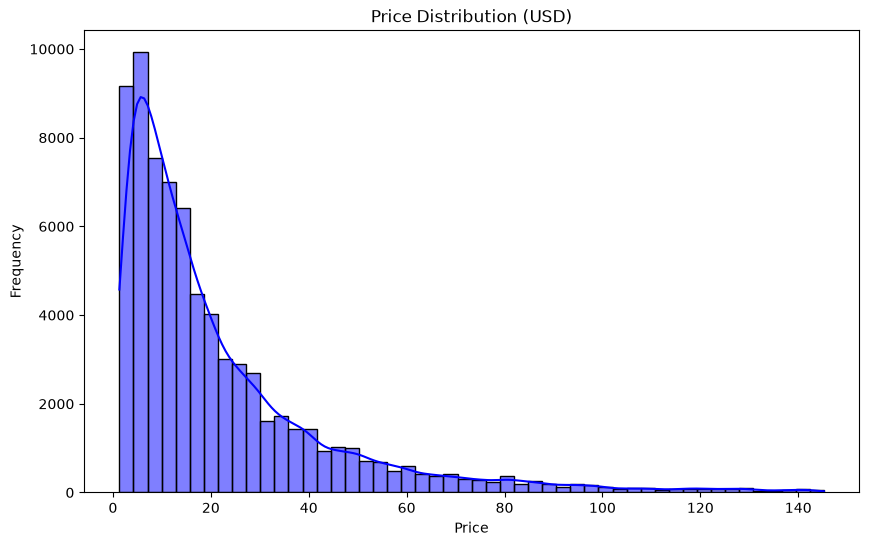

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Price Distribution (USD)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [3]:
print("Basic Price Statistics (USD):")
print(df['price'].describe())

Basic Price Statistics (USD):
count    73517.000000
mean        21.838957
std         22.624984
min          1.320000
25%          6.970000
50%         14.000000
75%         28.000000
max        145.250000
Name: price, dtype: float64


## 2. Train / Val / Test Split

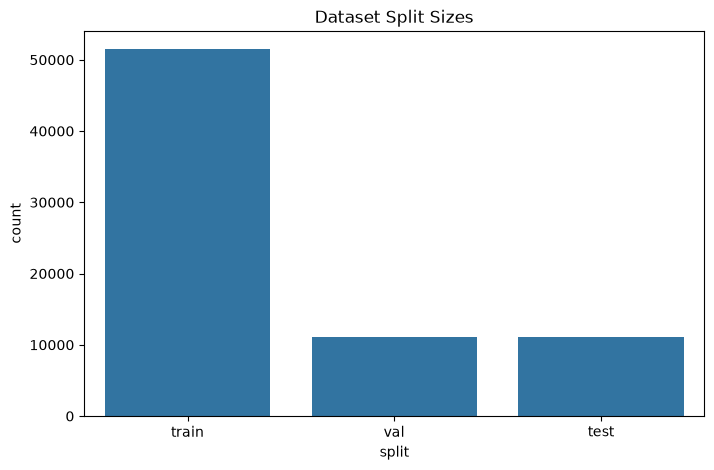

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='split', order=['train', 'val', 'test'])
plt.title('Dataset Split Sizes')
plt.show()

## 3. Sample Images Visual Sanity Check
Let's download a few sample images directly from the URLs and display them with their prices.

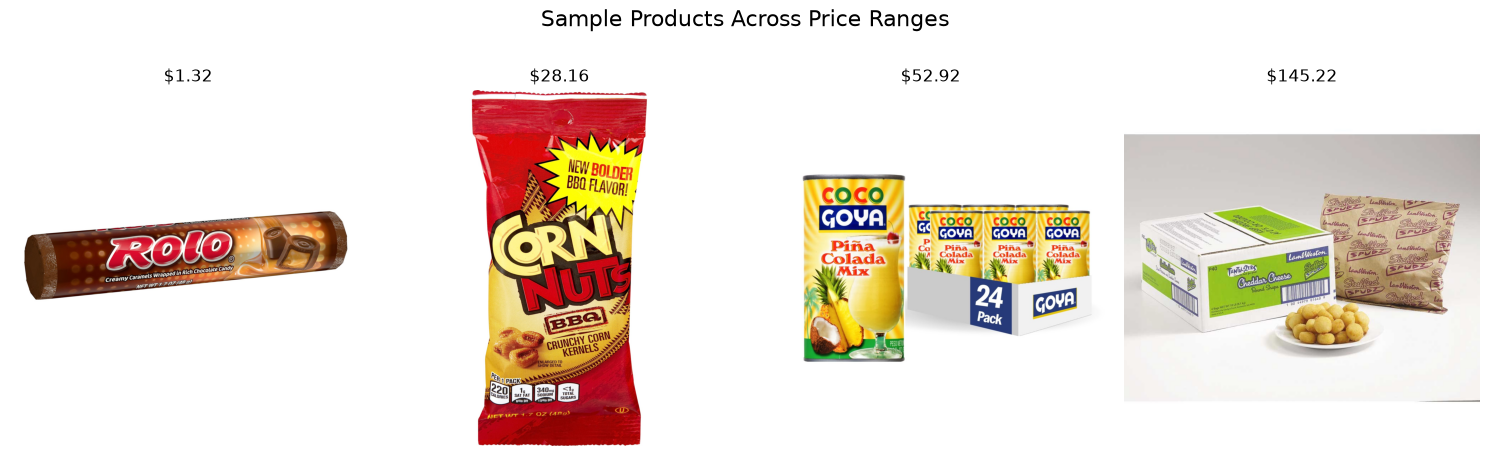

In [5]:
def show_sample_images(df_sample, title):
    fig, axes = plt.subplots(1, len(df_sample), figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    
    for ax, (_, row) in zip(axes, df_sample.iterrows()):
        try:
            response = requests.get(row['image_link'], timeout=5)
            img = Image.open(BytesIO(response.content))
            ax.imshow(img)
            ax.set_title(f"${row['price']:.2f}")
            ax.axis('off')
        except Exception as e:
            ax.set_title("Image Load Failed")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

# Sample 4 images from different price quartiles
low_price = df.nsmallest(10, 'price').sample(1)
high_price = df.nlargest(10, 'price').sample(1)
med_price1 = df[(df['price'] > 20) & (df['price'] < 30)].sample(1)
med_price2 = df[(df['price'] > 50) & (df['price'] < 60)].sample(1)

sample_df = pd.concat([low_price, med_price1, med_price2, high_price])
show_sample_images(sample_df, "Sample Products Across Price Ranges")

## 4. Data Quality Observations
- The dataset contains image links rather than raw images, meaning real-time download is required or a separate image scraping step is needed.
- The dataset does not have explicit category labels in isolated columns, only a `catalog_content` text field. To stratify by category in the future, we would need NLP to parse this field.
- Some image URLs may break over time (404 errors), which requires handling during dataset preparation for training.